In [1]:
from datasets.batch_integration import BatchIntDataset
from utils.experiment_utils import get_all_experiments_info, load_best_model
from utils.eval_utils import compute_mmd_distance, compute_sw_distance
import os

import scvi
import scanpy as sc
import pandas as pd
from collections import defaultdict
from sklearn.neighbors import NearestNeighbors

import hydra
from omegaconf import OmegaConf

import torch
import numpy as np
from geomloss import SamplesLoss

# silence all warnings
import warnings
warnings.filterwarnings("ignore")

/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/home/002/gokulg/miniforge3/envs/gde/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
n_pcs = 10
train_set = BatchIntDataset(
    root="data",
    split="train",
    n_pcs=n_pcs
)

test_set = BatchIntDataset(
    root="data",
    split="test",
    n_pcs=n_pcs
)

data loaded !
n train donors: 53
n test donors: 3
data loaded !
n train donors: 53
n test donors: 3


In [3]:
adata = test_set.adata

In [4]:
train_donors = train_set.donors
test_donors = test_set.donors
print(train_donors)
print(test_donors)

['mouse_pancreatic_islet_atlas_Hrovatin__Fltp_P16__145_mGFP', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_P16__146_mRFP', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_P16__147_mTmG', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse1', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse2', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse3', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_adult__mouse4', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD__SRR10985097', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD__SRR10985098', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD__SRR10985099', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610295', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610296', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610297', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610298', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_elimination__SRR7610299', 'mouse_pancreatic_islet_atlas_Hrovatin__NOD_e

In [5]:
donor_centroids = {}
for donor in test_donors:
    donor_data = test_set.adata[test_set.adata.obs['donor_id'] == donor]
    centroid = np.nan_to_num(donor_data.obsm['X_pca']).mean(axis=0).flatten()
    donor_centroids[donor] = centroid
for donor in train_donors:
    donor_data = train_set.adata[train_set.adata.obs['donor_id'] == donor]
    centroid = np.nan_to_num(donor_data.obsm['X_pca']).mean(axis=0).flatten()
    donor_centroids[donor] = centroid

# for each test donor, get the nearest train donor
test_to_train_donor = {}
for test_donor in test_donors:
    test_centroid = donor_centroids[test_donor]
    nearest_train_donor = None
    nearest_distance = float('inf')
    for train_donor in train_donors:
        train_centroid = donor_centroids[train_donor]
        distance = torch.norm(torch.tensor(test_centroid) - torch.tensor(train_centroid)).item()
        if distance < nearest_distance:
            nearest_distance = distance
            nearest_train_donor = train_donor
    test_to_train_donor[test_donor] = nearest_train_donor

print("Test to Train Donor Mapping:")
for test_donor, train_donor in test_to_train_donor.items():
    print(f"{test_donor} -> {train_donor}")

Test to Train Donor Mapping:
mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13974 -> mouse_pancreatic_islet_atlas_Hrovatin__VSG__MUC13632
mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13975 -> mouse_pancreatic_islet_atlas_Hrovatin__VSG__MUC13639
mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13976 -> mouse_pancreatic_islet_atlas_Hrovatin__VSG__MUC13634


In [14]:
cfgs[5]['config']['generator']

{'_target_': 'generator.direct.DirectGenerator', 'model': '${model}', 'loss_type': 'swd', 'noise_dim': '${experiment.latent_dim}', 'loss_params': {'n_projections': 100, 'p': 2}}

In [15]:
configs = get_all_experiments_info('/orcd/home/002/gokulg/orcd/scratch/CoupledDistributionEmbeddings/outputs/', False)

cfgs = [c for c in configs if 'batchint' in c['name']]

energy_models = [c for c in cfgs if 'mmd' in c['config']['generator'].values()]
swd_models = [c for c in cfgs if 'swd' in c['config']['generator'].values()]
fm_models = [c for c in cfgs if 'Flow' in c['generator']]

print("energy models:")
for model in energy_models:
    print(model['name'])

print("fm models:")
for model in fm_models:
    print(model['name'])

print("swd models:")
for model in swd_models:
    print(model['name'])

energy models:
batchint_7534e8f0d7380b40d45cc045a7058ed0
batchint_onehot_mmd_e6afbbfa465c531d61d8eb23deb4442d
fm models:
batchint_onehot_fm_43d4b1444a40bc41b753c4b0b52555fd
batchint_fm_e28de921f698e0d64cbbc03f2a4d0f2b
swd models:
batchint_cc4823e66038dc2ba7dc4e0442564418
batchint_onehot_mmd_e5716b717c1fc32467107e00744d9829


In [16]:
def load_model(cfg, path, device):
    enc = hydra.utils.instantiate(cfg['encoder'])
    gen = hydra.utils.instantiate(cfg['generator'])
    state = load_best_model(path)
    enc.load_state_dict(state['encoder_state_dict'])
    gen.load_state_dict(state['generator_state_dict'])
    enc.eval()
    gen.eval()
    enc.to(device)
    gen.to(device)
    return enc, gen

In [17]:
def evaluate_model_pair(encoder, generator, test_set, train_set, test_to_train_donor, 
                        model_type, device, n_pcs=10, n_samples=10):

    energy = SamplesLoss("energy")
    
    results = {
        'energy': [],
        'mmd': [],
        'sw': []
    }
    
    for p in range(len(test_set)):
        for _ in range(n_samples):
            batch = test_set[p]
            
            source_samples = batch['source_samples'].to(device).unsqueeze(0)
            target_samples = batch['target_samples'].to(device).unsqueeze(0)
            
            # Generate samples based on model type
            if model_type == 'onehot':
                source_donor = batch['source_metadata']['donor_id']
                target_donor = batch['target_metadata']['donor_id']
                
                nearest_source_donor = test_to_train_donor[source_donor]
                nearest_target_donor = test_to_train_donor[target_donor]
                
                nn_source_idx = torch.tensor(train_set.donors.index(nearest_source_donor)).to(device)
                nn_target_idx = torch.tensor(train_set.donors.index(nearest_target_donor)).to(device)
                
                with torch.no_grad():
                    source_latent = encoder(nn_source_idx).repeat(source_samples.shape[0], 1)
                    target_latent = encoder(nn_target_idx).repeat(target_samples.shape[0], 1)
                    samples = generator.sample(source_samples.reshape(-1, n_pcs), source_latent, target_latent)
            else: 
                with torch.no_grad():
                    source_latent = encoder(source_samples)
                    target_latent = encoder(target_samples)
                    samples = generator.sample(source_samples.reshape(-1, n_pcs), source_latent, target_latent)
            
            # Compute all metrics
            results['energy'].append(energy(samples.squeeze(0), target_samples.squeeze(0)).item())
            results['mmd'].append(compute_mmd_distance(samples, target_samples).item())
            results['sw'].append(compute_sw_distance(samples, target_samples).item())
    
    return results

device = 'cuda'
all_results = {}

model_pairs = [
    ('energy_models', energy_models),
    ('fm_models', fm_models),
    ('swd_models', swd_models)
]

for model_group_name, model_group in model_pairs:
    print(f"evaluating {model_group_name}")
        
    dct_model = [c for c in model_group if 'Emb' not in c['encoder']]
    onehot_model = [c for c in model_group if 'Emb' in c['encoder']]
    
    if not dct_model or not onehot_model:
        print(f"Skipping {model_group_name}: missing DCT or OneHot model")
        continue
    
    dct_model = dct_model[0]
    onehot_model = onehot_model[0]
    
    dct_encoder, dct_generator = load_model(dct_model['config'], dct_model['dir'], device)
    dct_results = evaluate_model_pair(
        dct_encoder, dct_generator, test_set, train_set, 
        test_to_train_donor, 'dct', device, n_pcs=n_pcs
    )
    all_results[f'{model_group_name}_dct'] = dct_results
    
    onehot_encoder, onehot_generator = load_model(onehot_model['config'], onehot_model['dir'], device)
    onehot_results = evaluate_model_pair(
        onehot_encoder, onehot_generator, test_set, train_set,
        test_to_train_donor, 'onehot', device, n_pcs=n_pcs
    )
    all_results[f'{model_group_name}_onehot'] = onehot_results

print(f"{'Model':<30} {'Energy':<20} {'MMD':<20} {'SW':<20}")

for model_name, results in all_results.items():
    energy_str = f"{np.mean(results['energy']):.4f}\pm{np.std(results['energy'])/np.sqrt(len(results['energy'])):.4f}"
    mmd_str = f"{np.mean(results['mmd']):.4f}\pm{np.std(results['mmd'])/np.sqrt(len(results['mmd'])):.4f}"
    sw_str = f"{np.mean(results['sw']):.4f}\pm{np.std(results['sw'])/np.sqrt(len(results['sw'])):.4f}"
    print(f"{model_name:<30} {energy_str:<20} {mmd_str:<20} {sw_str:<20}")

evaluating energy_models
evaluating fm_models
evaluating swd_models
Model                          Energy               MMD                  SW                  
energy_models_dct              0.0729\pm0.0090      0.1459\pm0.0181      0.3551\pm0.0354     
energy_models_onehot           0.3623\pm0.0327      0.7245\pm0.0655      0.5998\pm0.0344     
fm_models_dct                  0.1480\pm0.0157      0.2960\pm0.0315      0.4532\pm0.0361     
fm_models_onehot               0.4235\pm0.0540      0.8470\pm0.1080      0.5448\pm0.0425     
swd_models_dct                 0.1167\pm0.0119      0.2334\pm0.0239      0.3161\pm0.0326     
swd_models_onehot              0.3411\pm0.0351      0.6822\pm0.0702      0.4865\pm0.0317     


In [18]:
# scVI model evaluation with all three metrics
adata_scvi = adata.copy()

scvi.model.SCVI.setup_anndata(
    adata_scvi,
    batch_key="donor_id",
    layer='counts'
)

model = scvi.model.SCVI.load('/orcd/home/002/gokulg/orcd/scratch/CoupledDistributionEmbeddings/outputs/batch_scvi_model', adata_scvi)

# fit nearest neighbors on adata
nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(adata_scvi.X)

energy = SamplesLoss("energy")

all_results['scvi'] = {
    'energy': [],
    'mmd': [],
    'sw': []
}

for p in range(len(test_set)):
    batches_info = []
    for _ in range(10):
        batch = test_set[p]
        batches_info.append(batch)
    
    # Group by target donor to batch the scVI calls
    donor_groups = defaultdict(list)
    for i, batch in enumerate(batches_info):
        target_donor = batch['target_metadata']['donor_id']
        donor_groups[target_donor].append((i, batch))
    
    # Process each donor group together
    results = [None] * 10
    for target_donor, group in donor_groups.items():
        # Combine all source indices for this target donor
        all_source_inds = np.concatenate([b['source_metadata']['adata_indices'] for _, b in group])
        adata_source = adata_scvi[all_source_inds].copy()
        
        # Single scVI call for all samples going to this donor
        transformed = model.get_normalized_expression(
            adata_source, batch_size=512, transform_batch=target_donor
        )
        
        # Split results back
        offset = 0
        for i, batch in group:
            n_samples = len(batch['source_metadata']['adata_indices'])
            results[i] = (transformed[offset:offset+n_samples], batch['target_samples'])
            offset += n_samples
    
    # Compute all three metrics
    for transformed, target_samples in results:
        nns = nbrs.kneighbors(transformed, return_distance=False)
        snapped = adata_scvi.obsm['X_pca'][nns.flatten(), :10]
        
        # Convert to torch tensor
        snapped_tensor = torch.tensor(snapped, dtype=torch.float32)
        
        # Compute energy distance
        e_dist = energy(snapped_tensor, target_samples.squeeze(0)).item()
        all_results['scvi']['energy'].append(e_dist)
        
        # Compute MMD distance
        mmd_dist = compute_mmd_distance(snapped_tensor.unsqueeze(0), target_samples).item()
        all_results['scvi']['mmd'].append(mmd_dist)
        
        # Compute SW distance
        sw_dist = compute_sw_distance(snapped_tensor.unsqueeze(0), target_samples).item()
        all_results['scvi']['sw'].append(sw_dist)

print(f"{'Model':<30} {'Energy':<20} {'MMD':<20} {'SW':<20}")
for model_name, results in all_results.items():
    energy_str = f"{np.mean(results['energy']):.4f}\pm{np.std(results['energy'])/np.sqrt(len(results['energy'])):.4f}"
    mmd_str = f"{np.mean(results['mmd']):.4f}\pm{np.std(results['mmd'])/np.sqrt(len(results['mmd'])):.4f}"
    sw_str = f"{np.mean(results['sw']):.4f}\pm{np.std(results['sw'])/np.sqrt(len(results['sw'])):.4f}"
    print(f"{model_name:<30} {energy_str:<20} {mmd_str:<20} {sw_str:<20}")

INFO     File /orcd/home/002/gokulg/orcd/scratch/CoupledDistributionEmbeddings/outputs/batch_scvi_model/model.pt   
         already downloaded                                                                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer set

In [19]:
table_data = []

model_groups = [
    ('energy_models', 'Energy'),
    ('fm_models', 'Flow Matching'),
    ('swd_models', 'Sliced-Wasserstein')
]

for group_name, display_name in model_groups:
    for encoder_type in ['dct', 'onehot']:
        model_key = f'{group_name}_{encoder_type}'
        if model_key in all_results:
            results = all_results[model_key]
            
            # Compute mean ± SEM for each metric
            energy_mean = np.mean(results['energy'])
            energy_sem = np.std(results['energy']) / np.sqrt(len(results['energy']))
            
            sw_mean = np.mean(results['sw'])
            sw_sem = np.std(results['sw']) / np.sqrt(len(results['sw']))
            
            mmd_mean = np.mean(results['mmd'])
            mmd_sem = np.std(results['mmd']) / np.sqrt(len(results['mmd']))
            
            encoder_display = 'DCT' if encoder_type == 'dct' else 'One-hot'
            model_name = f'{encoder_display} ({display_name})'
            
            table_data.append({
                'Model': model_name,
                'Energy': f'{energy_mean:.4f} $\\pm$ {energy_sem:.4f}',
                'SW': f'{sw_mean:.4f} $\\pm$ {sw_sem:.4f}',
                'MMD': f'{mmd_mean:.4f} $\\pm$ {mmd_sem:.4f}'
            })
    
    table_data.append({'separator': True})

if 'scvi' in all_results:
    results = all_results['scvi']
    
    energy_mean = np.mean(results['energy'])
    energy_sem = np.std(results['energy']) / np.sqrt(len(results['energy']))
    
    sw_mean = np.mean(results['sw'])
    sw_sem = np.std(results['sw']) / np.sqrt(len(results['sw']))
    
    mmd_mean = np.mean(results['mmd'])
    mmd_sem = np.std(results['mmd']) / np.sqrt(len(results['mmd']))
    
    table_data.append({
        'Model': 'scVI',
        'Energy': f'{energy_mean:.4f} $\\pm$ {energy_sem:.4f}',
        'SW': f'{sw_mean:.4f} $\\pm$ {sw_sem:.4f}',
        'MMD': f'{mmd_mean:.4f} $\\pm$ {mmd_sem:.4f}'
    })

# Generate LaTeX table
latex_lines = [
    r'\begin{tabular}{lccc}',
    r'\toprule',
    r'Model & Energy Distance & Sliced-Wasserstein & MMD (RBF) \\',
    r'\midrule'
]

for row in table_data:
    if row.get('separator'):
        latex_lines.append(r'\midrule')
    else:
        latex_lines.append(f"{row['Model']} & {row['Energy']} & {row['SW']} & {row['MMD']} \\\\")

latex_lines.extend([
    r'\bottomrule',
    r'\end{tabular}'
])

latex_table = '\n'.join(latex_lines)
print(latex_table)

\begin{tabular}{lccc}
\toprule
Model & Energy Distance & Sliced-Wasserstein & MMD (RBF) \\
\midrule
DCT (Energy) & 0.0729 $\pm$ 0.0090 & 0.3551 $\pm$ 0.0354 & 0.1459 $\pm$ 0.0181 \\
One-hot (Energy) & 0.3623 $\pm$ 0.0327 & 0.5998 $\pm$ 0.0344 & 0.7245 $\pm$ 0.0655 \\
\midrule
DCT (Flow Matching) & 0.1480 $\pm$ 0.0157 & 0.4532 $\pm$ 0.0361 & 0.2960 $\pm$ 0.0315 \\
One-hot (Flow Matching) & 0.4235 $\pm$ 0.0540 & 0.5448 $\pm$ 0.0425 & 0.8470 $\pm$ 0.1080 \\
\midrule
DCT (Sliced-Wasserstein) & 0.1167 $\pm$ 0.0119 & 0.3161 $\pm$ 0.0326 & 0.2334 $\pm$ 0.0239 \\
One-hot (Sliced-Wasserstein) & 0.3411 $\pm$ 0.0351 & 0.4865 $\pm$ 0.0317 & 0.6822 $\pm$ 0.0702 \\
\midrule
scVI & 0.8056 $\pm$ 0.0643 & 0.6190 $\pm$ 0.0630 & 1.6112 $\pm$ 0.1286 \\
\bottomrule
\end{tabular}


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Source donor: mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13974
Target donors: ['mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13975', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13976']
Source has 7534 cells


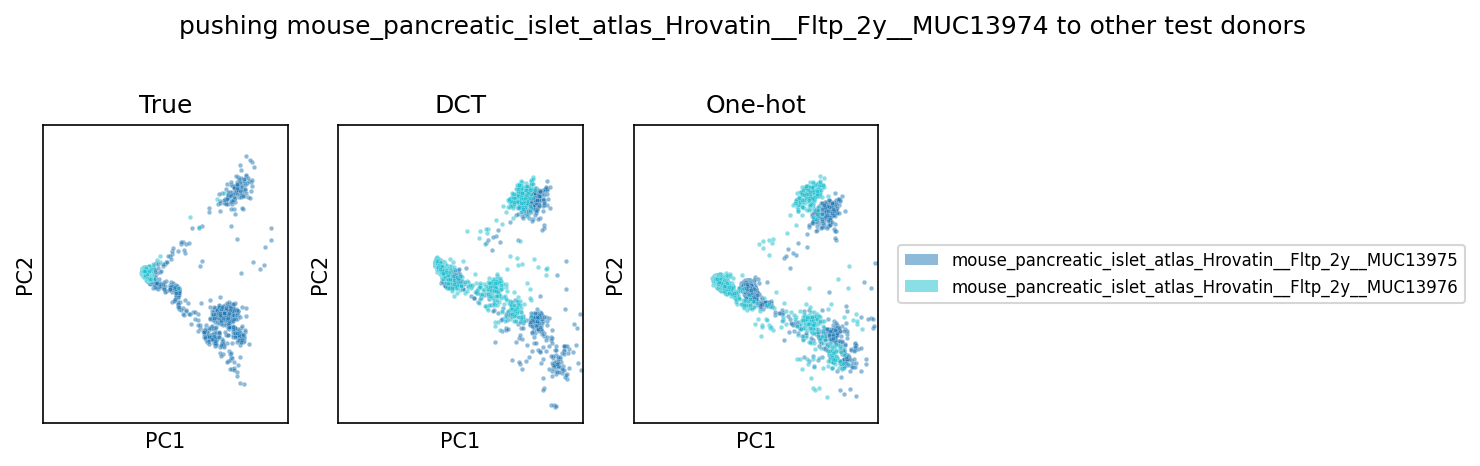

Source donor: mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13975
Target donors: ['mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13974', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13976']
Source has 3746 cells


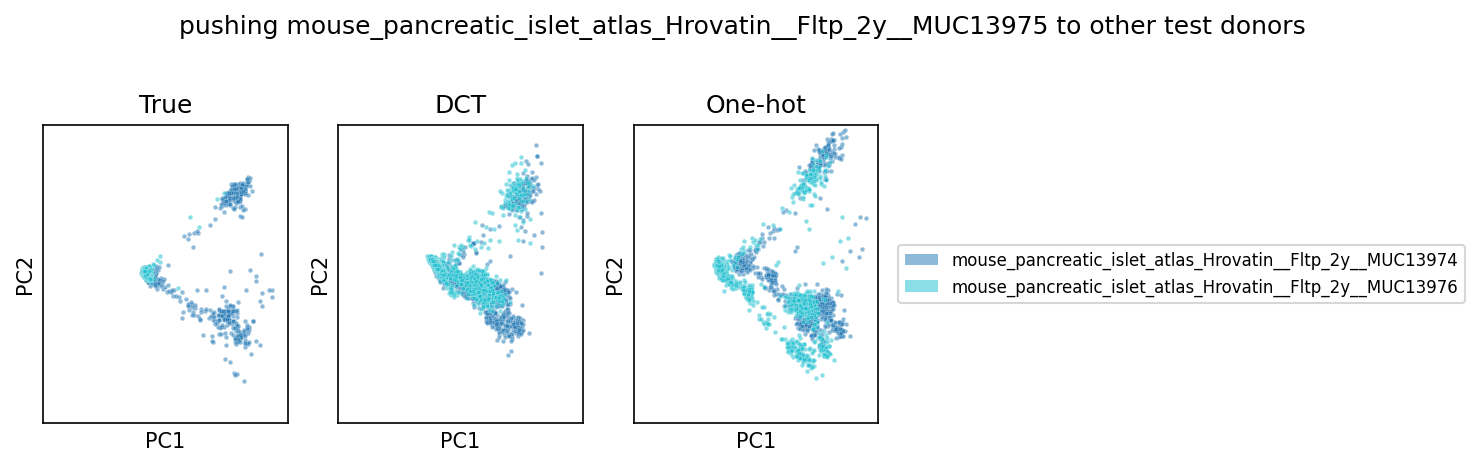

Source donor: mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13976
Target donors: ['mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13974', 'mouse_pancreatic_islet_atlas_Hrovatin__Fltp_2y__MUC13975']
Source has 6081 cells


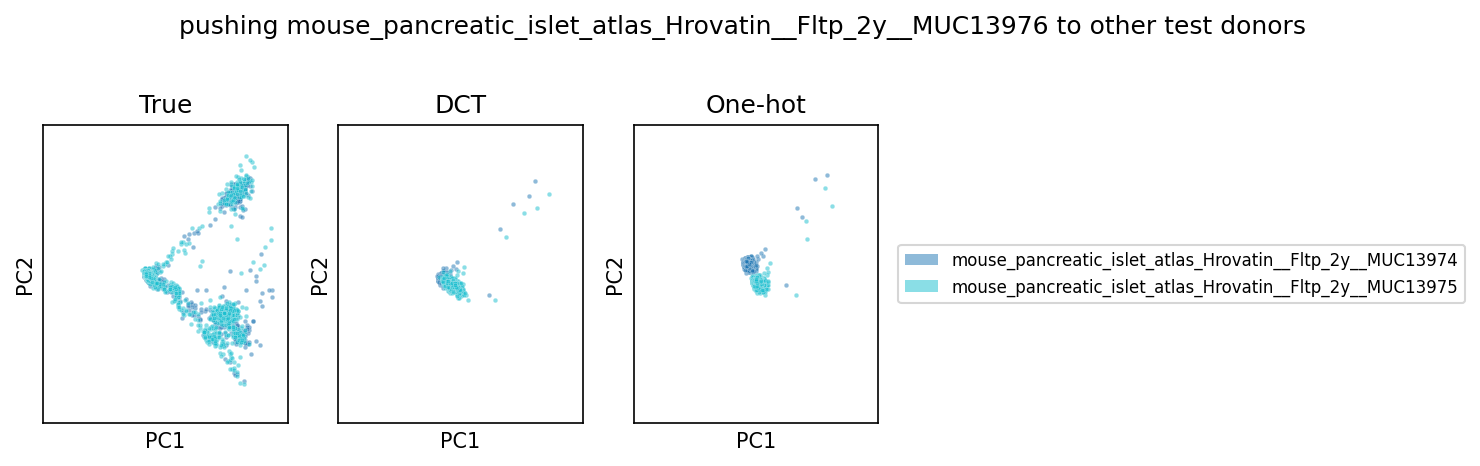

In [ ]:
for source_donor in test_donors:

    print(f"Source donor: {source_donor}")
    print(f"Target donors: {[d for d in test_donors if d != source_donor]}")

    # Get all cells from source donor
    source_mask = adata.obs['donor_id'] == source_donor
    source_cells = adata[source_mask]
    source_pca = source_cells.obsm['X_pca'][:, :10]
    source_indices = np.where(source_mask)[0]

    print(f"Source has {len(source_pca)} cells")

    # Prepare data structures for predictions
    all_target_donors = [d for d in test_donors if d != source_donor]
    predictions = {
        'true': [],
        'dct': [],
        'onehot': [],
        # 'scvi': []
    }
    donor_labels = {
        'true': [],
        'dct': [],
        'onehot': [],
        # 'scvi': []
    }

    # For each target donor, get true data and predictions
    for target_donor in all_target_donors:
        # Get true target cells
        target_mask = adata.obs['donor_id'] == target_donor
        target_cells = adata[target_mask]
        target_pca = target_cells.obsm['X_pca'][:, :10]
        
        predictions['true'].append(target_pca)
        donor_labels['true'].extend([target_donor] * len(target_pca))
        
        # Prepare source data as tensors
        source_tensor = torch.tensor(source_pca, dtype=torch.float32).to(device)
        target_tensor = torch.tensor(target_pca, dtype=torch.float32).to(device)
        
        # DCT predictions
        with torch.no_grad():
            source_latent = dct_encoder(source_tensor.unsqueeze(0))
            target_latent = dct_encoder(target_tensor.unsqueeze(0))
            dct_pred = dct_generator.sample(source_tensor, source_latent, target_latent)
        
        # Ensure 2D shape (n_cells, n_features)
        dct_pred = dct_pred.squeeze()
        if len(dct_pred.shape) == 1:
            dct_pred = dct_pred.unsqueeze(0)
        predictions['dct'].append(dct_pred.cpu().numpy())
        donor_labels['dct'].extend([target_donor] * len(dct_pred))
        
        # OneHot predictions
        nearest_source_donor = test_to_train_donor[source_donor]
        nearest_target_donor = test_to_train_donor[target_donor]
        nn_source_idx = torch.tensor(train_set.donors.index(nearest_source_donor)).cuda()
        nn_target_idx = torch.tensor(train_set.donors.index(nearest_target_donor)).cuda()
        
        with torch.no_grad():
            onehot_source_latent = onehot_encoder(nn_source_idx).repeat(len(source_tensor), 1)
            onehot_target_latent = onehot_encoder(nn_target_idx).repeat(len(source_tensor), 1)
            onehot_pred = onehot_generator.sample(source_tensor, onehot_source_latent, onehot_target_latent)
        
        # Ensure 2D shape (n_cells, n_features)
        onehot_pred = onehot_pred.squeeze()
        if len(onehot_pred.shape) == 1:
            onehot_pred = onehot_pred.unsqueeze(0)
        predictions['onehot'].append(onehot_pred.cpu().numpy())
        donor_labels['onehot'].extend([target_donor] * len(onehot_pred))
        
        # # scVI predictions
        # adata_source = adata_scvi[source_indices].copy()
        # transformed = model.get_normalized_expression(
        #     adata_source, batch_size=512, transform_batch=target_donor
        # )
        # nns = nbrs.kneighbors(transformed, return_distance=False)
        # scvi_pred = adata_scvi.obsm['X_pca'][nns.flatten(), :10]
        # predictions['scvi'].append(scvi_pred)
        # donor_labels['scvi'].extend([target_donor] * len(scvi_pred))

    # Concatenate all predictions
    for method in predictions:
        predictions[method] = np.vstack(predictions[method])

    # Create the 3-panel plot
    fig, axes = plt.subplots(1, 3, figsize=(10, 3), dpi=150)

    methods = ['true', 'dct', 'onehot']
    titles = ['True', 'DCT', 'One-hot']

    # Use consistent colors for donors across all subplots
    colors = plt.cm.tab10(np.linspace(0, 1, len(all_target_donors)))
    donor_colors = dict(zip(all_target_donors, colors))
    
    for ax, method, title in zip(axes, methods, titles):
        data = predictions[method]
        labels = donor_labels[method]
        
        # Plot with different colors for each target donor
        for target_donor in all_target_donors:
            mask = np.array(labels) == target_donor
            # sns.kdeplot(
            #     x=data[mask, 0],
            #     y=data[mask, 1],
            #     ax=ax,
            #     fill=True,
            #     alpha=0.5,
            #     color=donor_colors[target_donor],
            #     thresh=0.05,
            #     levels=3,
            #     gridsize=50
            # )
            sns.scatterplot(
                x=data[mask, 0],
                y=data[mask, 1],
                ax=ax,
                alpha=0.5,
                color=donor_colors[target_donor],
                s=5
            )
        
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_title(title)

    # Create custom legend patches
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=donor_colors[donor], alpha=0.5, label=donor) 
                      for donor in all_target_donors]
    
    # Add legend to the right of the third subplot
    axes[-1].legend(handles=legend_elements, fontsize=8, loc='center left', bbox_to_anchor=(1.05, 0.5))

    plt.suptitle(f'pushing {source_donor} to other test donors', y=1.02)
    plt.tight_layout()
    plt.show()